# 3. Hyperparameter tuning with validation curves

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
DATA_PATH = Path("../data")
FIGURES_PATH = Path("../figures")
SCORING_METRICS = ["roc_auc", "f1"]

## Load train set (the test set is not used in this notebook)

In [2]:
train_data = pd.read_csv(DATA_PATH / "train_processed.csv")

X_train = train_data.drop(columns="y")
y_train = train_data["y"]

categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
numerical_features = X_train.select_dtypes(include="number").columns.tolist()

## Same preprocessing and stratified 5-fold as notebook 2

In [3]:
preprocessor = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_features),
    ("categorical", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                  min_frequency=100,
                                  sparse_output=False), categorical_features),
])

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Validation curve: train and validation scores for each hyperparameter value

In [4]:
def evaluate_hyperparameter(classifier, parameter_name, parameter_values):
    classification_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", classifier),
    ])
    curve_results = []
    for parameter_value in parameter_values:
        classification_pipeline.set_params(**{f"classifier__{parameter_name}": parameter_value})
        fold_scores = cross_validate(
            classification_pipeline, X_train, y_train,
            cv=stratified_kfold,
            scoring=SCORING_METRICS,
            return_train_score=True,
            n_jobs=-1,
        )
        curve_results.append({
            parameter_name: parameter_value,
            "train_roc_auc": fold_scores["train_roc_auc"].mean(),
            "validation_roc_auc": fold_scores["test_roc_auc"].mean(),
            "train_f1": fold_scores["train_f1"].mean(),
            "validation_f1": fold_scores["test_f1"].mean(),
        })
        print(f"{parameter_name} = {parameter_value}: done")
    return pd.DataFrame(curve_results)

## Best value: highest validation ROC-AUC

In [5]:
def plot_validation_curve(curve_results, parameter_name, title, figure_name, log_scale=False):
    best_value = curve_results.loc[curve_results["validation_roc_auc"].idxmax(), parameter_name]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in zip(axes, SCORING_METRICS):
        ax.plot(curve_results[parameter_name], curve_results[f"train_{metric}"],
                marker="o", label="train")
        ax.plot(curve_results[parameter_name], curve_results[f"validation_{metric}"],
                marker="o", label="validation")
        ax.axvline(best_value, color="gray", linestyle="--", label=f"best = {best_value}")
        if log_scale:
            ax.set_xscale("log")
        ax.set_xlabel(parameter_name)
        ax.set_ylabel(metric)
        ax.legend()
    fig.suptitle(title)
    plt.savefig(FIGURES_PATH / figure_name, bbox_inches="tight")
    plt.show()
    return best_value

## SVM: regularization parameter C

In [6]:
svm_curve = evaluate_hyperparameter(
    SVC(class_weight="balanced", random_state=RANDOM_STATE),
    parameter_name="C",
    parameter_values=[0.01, 0.1, 1, 10],
)
svm_curve.round(3)

C = 0.01: done
C = 0.1: done
C = 1: done
C = 10: done


,C,train_roc_auc,validation_roc_auc,train_f1,validation_f1
0,0.01,0.780,0.772,0.405,0.403
1,0.10,0.819,0.774,0.469,0.466
2,1.00,0.851,0.772,0.487,0.470
3,10.00,0.888,0.749,0.555,0.420


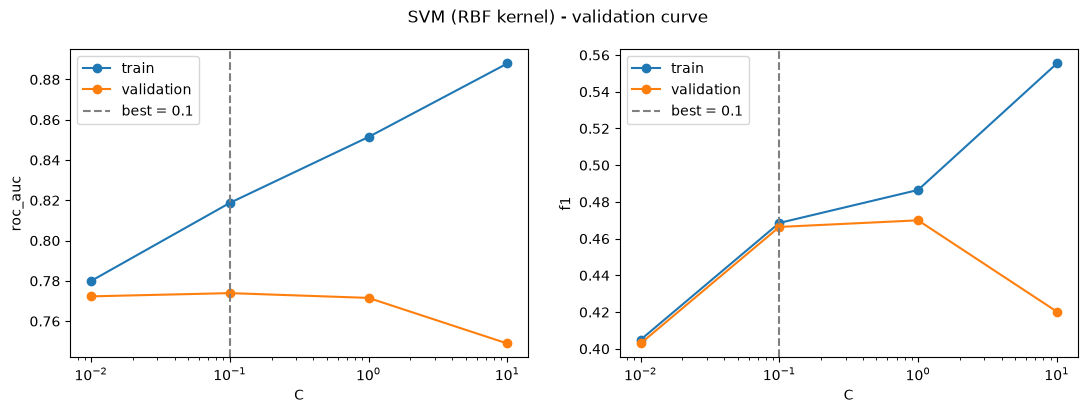

In [7]:
best_svm_c = plot_validation_curve(svm_curve, "C", "SVM (RBF kernel) - validation curve",
                                   "07_validation_curve_svm.png", log_scale=True)

## KNN: number of neighbors

In [8]:
knn_curve = evaluate_hyperparameter(
    KNeighborsClassifier(),
    parameter_name="n_neighbors",
    parameter_values=[1, 5, 15, 31, 51, 101, 201, 401],
)
knn_curve.round(3)

n_neighbors = 1: done
n_neighbors = 5: done
n_neighbors = 15: done
n_neighbors = 31: done
n_neighbors = 51: done
n_neighbors = 101: done
n_neighbors = 201: done
n_neighbors = 401: done


,n_neighbors,train_roc_auc,validation_roc_auc,train_f1,validation_f1
0,1,0.932,0.622,0.883,0.329
1,5,0.924,0.731,0.503,0.369
2,15,0.871,0.762,0.410,0.372
3,31,0.842,0.770,0.372,0.355
4,51,0.825,0.775,0.360,0.344
5,101,0.809,0.779,0.338,0.332
6,201,0.801,0.783,0.321,0.317
7,401,0.794,0.785,0.317,0.317


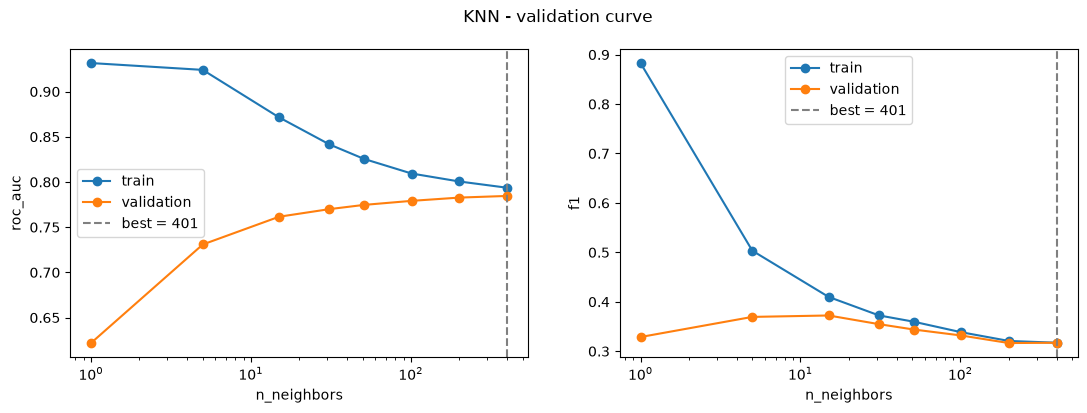

In [9]:
best_knn_neighbors = plot_validation_curve(knn_curve, "n_neighbors", "KNN - validation curve",
                                           "08_validation_curve_knn.png", log_scale=True)

## Random Forest: maximum depth of the trees

In [10]:
random_forest_curve = evaluate_hyperparameter(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    parameter_name="max_depth",
    parameter_values=[2, 4, 6, 8, 10, 12, 15, 20, 25],
)
random_forest_curve.round(3)

max_depth = 2: done
max_depth = 4: done
max_depth = 6: done
max_depth = 8: done
max_depth = 10: done
max_depth = 12: done
max_depth = 15: done
max_depth = 20: done
max_depth = 25: done


,max_depth,train_roc_auc,validation_roc_auc,train_f1,validation_f1
0,2,0.779,0.778,0.444,0.441
1,4,0.791,0.788,0.461,0.460
2,6,0.802,0.792,0.468,0.466
3,8,0.819,0.794,0.480,0.471
4,10,0.842,0.795,0.497,0.476
5,12,0.875,0.792,0.526,0.476
6,15,0.927,0.785,0.600,0.472
7,20,0.983,0.767,0.765,0.441
8,25,0.995,0.752,0.820,0.402


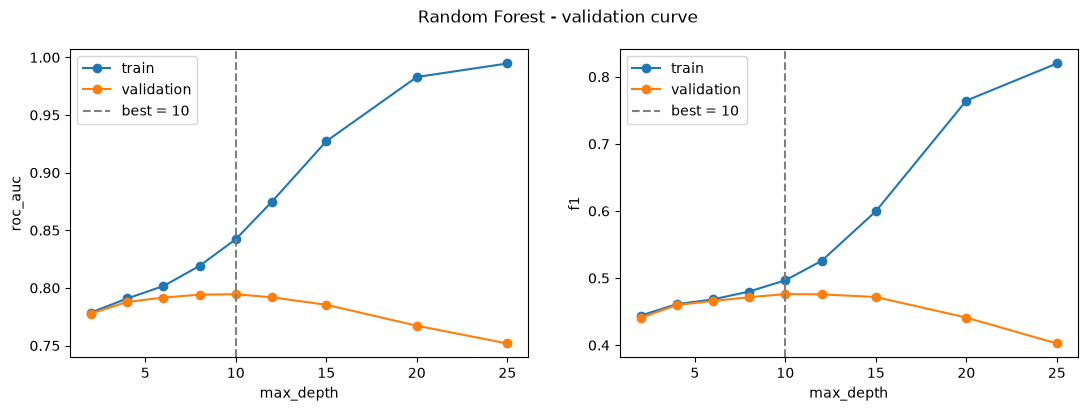

In [11]:
best_random_forest_depth = plot_validation_curve(random_forest_curve, "max_depth",
                                                 "Random Forest - validation curve",
                                                 "09_validation_curve_random_forest.png")

## Summary of tuned models (validation scores of the best value)

In [12]:
tuned_results = pd.DataFrame([
    {"classifier": f"SVM (C={best_svm_c})",
     **svm_curve.loc[svm_curve["C"] == best_svm_c].iloc[0, 1:]},
    {"classifier": f"KNN (k={best_knn_neighbors})",
     **knn_curve.loc[knn_curve["n_neighbors"] == best_knn_neighbors].iloc[0, 1:]},
    {"classifier": f"Random Forest (max_depth={best_random_forest_depth})",
     **random_forest_curve.loc[random_forest_curve["max_depth"] == best_random_forest_depth].iloc[0, 1:]},
]).set_index("classifier")
tuned_results.round(3)

,train_roc_auc,validation_roc_auc,train_f1,validation_f1
classifier,,,,
SVM (C=0.1),0.819,0.774,0.469,0.466
KNN (k=401),0.794,0.785,0.317,0.317
Random Forest (max_depth=10),0.842,0.795,0.497,0.476


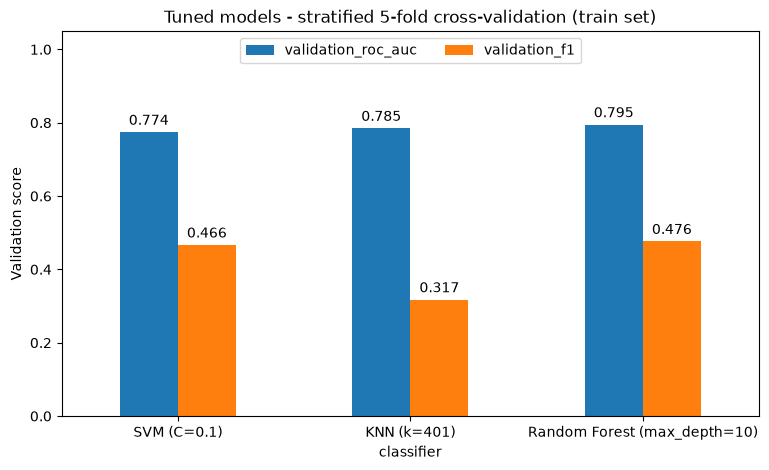

In [13]:
ax = tuned_results[["validation_roc_auc", "validation_f1"]].plot(kind="bar", figsize=(9, 5), rot=0)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper center", ncols=2)
ax.set_ylabel("Validation score")
ax.set_title("Tuned models - stratified 5-fold cross-validation (train set)")
plt.savefig(FIGURES_PATH / "10_tuned_models_comparison.png", bbox_inches="tight")
plt.show()